<a href="https://www.kaggle.com/code/zulqarnain11/breast-cancer-exploratory-analysis?scriptVersionId=290401140" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="border-radius:12px; padding:20px; background:#c8e6c9; border-left:8px solid #388e3c">
<h1 style="margin:0; color:#2e7d32;">Breast Cancer EDA</h1>
<p style="margin:5px 0 0 0; font-size:14px; color:#555;">Exploratory Data Analysis and Insights on Breast Cancer Patient Dataset</p>
</div>


# About the Author

<div style="border-radius:12px; padding:15px; background:#e0f7fa; border-left:5px solid #00acc1">
👤 <strong>Zulqarnain Haider</strong> – Data Scientist | Computer Vision & Machine Learning Enthusiast  

📌 **Connect with me:**  

<a href="https://www.kaggle.com/zulqarnainhaider" target="_blank" style="text-decoration:none;">
<span style="background:#00BFFF; color:white; padding:5px 12px; border-radius:5px; margin-right:5px;">Kaggle</span>
</a>
<a href="https://github.com/haider1272" target="_blank" style="text-decoration:none;">
<span style="background:#333333; color:white; padding:5px 12px; border-radius:5px; margin-right:5px;">GitHub</span>
</a>
<a href="https://www.linkedin.com/in/zulqarnain-haider-ba60143a0/" target="_blank" style="text-decoration:none;">
<span style="background:#0077B5; color:white; padding:5px 12px; border-radius:5px;">LinkedIn</span>
</a>
</div>


# About the Dataset

<div style="border-radius:12px; padding:15px; background:#fff3e0; border-left:5px solid #ff9800">
This dataset contains clinical information for **breast cancer patients**, including:  
- Age of patients  
- Tumor size  
- Number of regional lymph nodes examined and positive  
- Survival months  

It is useful for performing **exploratory data analysis (EDA)**, understanding patterns in breast cancer, and building predictive models.  

📌 **Access the dataset:**  

<a href="https://www.kaggle.com/datasets/reihanenamdari/breast-cancer" target="_blank" style="text-decoration:none;">
<span style="background:#ff9800; color:white; padding:5px 12px; border-radius:5px;">Kaggle Dataset</span>
</a>

</div>


## import Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')



In [28]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("reihanenamdari/breast-cancer")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/breast-cancer


In [29]:
import os
os.listdir(path)
os.path.join(path,'Breast_Cancer.csv')

'/kaggle/input/breast-cancer/Breast_Cancer.csv'

In [30]:

df = pd.read_csv(os.path.join(path,'Breast_Cancer.csv'))
df.head()


,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


## Missing Value Analysis

<div style="border-radius:15px; padding:20px; background:#f5f7fa; border-left:6px solid #4CAF50">
<p>This step checks whether the dataset contains missing or null values that could affect analysis or modeling.</p>
</div>


In [31]:
df.isnull().sum()


Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64

<div style="border-radius:12px; padding:15px; background:#f5faff; border-left:5px solid #4CAF50">
<strong>Missing Value Check:</strong>  
All features in the dataset contain <strong>zero missing values</strong>.  
This indicates a clean and well-prepared dataset, allowing reliable exploratory analysis and model training without the need for imputation.
</div>


## Statistical Summary:
<div style="border-radius:12px; padding:15px; background:#f5faff; border-left:5px solid #2196F3">
This section provides descriptive statistics for numerical features, helping understand data distribution, central tendency, and variability.
</div>


In [32]:
df.describe()


,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


<div style="border-radius:12px; padding:15px; background:#f5faff; border-left:5px solid #2196F3">
<strong>Statistical Interpretation:</strong>  
Patients are mostly middle-aged (median age ≈ 54 years). Tumor size and lymph node involvement show wide variability, indicating diverse disease severity. Survival months are relatively high on average, but the large spread suggests significant differences in patient outcomes.
</div>


## Age Distribution of Patients

<div style="border-radius:12px; padding:15px; background:#e0f7fa; border-left:5px solid #00acc1">
<strong>What is the age distribution of patients in this breast cancer dataset? Which age groups are most affected?</strong>
</div>


In [33]:
# 1️⃣ Numeric summary of Age
print("Age Statistics:")
print(df['Age'].describe())

# 2️⃣ Define age groups (bins)
age_bins = [20, 30, 40, 50, 60, 70, 80]
age_labels = ['21-30', '31-40', '41-50', '51-60', '61-70', '71-80']

# 3️⃣ Categorize ages into groups
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=True)

# 4️⃣ Count number of patients in each age group
age_group_counts = df['Age_Group'].value_counts().sort_index()
print("\nNumber of patients in each age group:")
print(age_group_counts)

# 5️⃣ Identify the most affected age group
most_affected = age_group_counts.idxmax()
count_most_affected = age_group_counts.max()
print(f"\nMost affected age group: {most_affected} with {count_most_affected} patients")


Age Statistics:
count    4024.000000
mean       53.972167
std         8.963134
min        30.000000
25%        47.000000
50%        54.000000
75%        61.000000
max        69.000000
Name: Age, dtype: float64

Number of patients in each age group:
Age_Group
21-30       5
31-40     297
41-50    1196
51-60    1386
61-70    1140
71-80       0
Name: count, dtype: int64

Most affected age group: 51-60 with 1386 patients


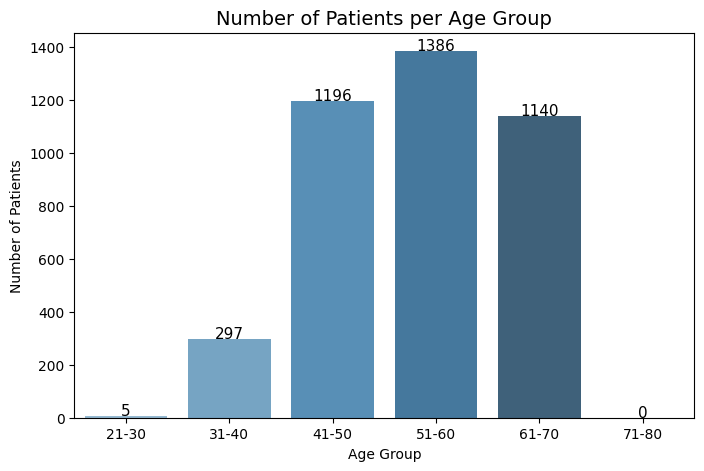

In [34]:
# Plot Age Group Distribution
plt.figure(figsize=(8,5))
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, palette="Blues_d")
plt.title("Number of Patients per Age Group", fontsize=14)
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

# Add value labels on top of bars
for i, count in enumerate(age_group_counts.values):
    plt.text(i, count + 2, str(count), ha='center', fontsize=11)

plt.show()


### Interpretation of Age Distribution

- The patients in this breast cancer dataset range from **30 to 69 years**, with an **average age of ~54 years**.  
- Most patients are **middle-aged**, as shown by the 25th, 50th, and 75th percentiles (47, 54, 61 years).  
- When grouped into age ranges:
  - **21-30:** 5 patients  
  - **31-40:** 297 patients  
  - **41-50:** 1196 patients  
  - **51-60:** 1386 patients (**most affected**)  
  - **61-70:** 1140 patients  
  - **71-80:** 0 patients  
- Breast cancer predominantly affects **middle-aged individuals**, with a peak in the **51-60 age group**.  
- Very few patients are below 31, and no patients are above 70.  

## Tumor Size Distribution

<div style="border-radius:12px; padding:15px; background:#e0f7fa; border-left:5px solid #00acc1">
<strong>What is the distribution of tumor sizes among patients? Which tumor size range is most common?</strong>
</div>


In [35]:
# Tumor Size Statistics
print("Tumor Size Statistics:")
print(df['Tumor Size'].describe())

# Define tumor size bins
tumor_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
tumor_labels = ['1-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80']

# Categorize tumor sizes
df['Tumor_Size_Group'] = pd.cut(df['Tumor Size'], bins=tumor_bins, labels=tumor_labels, right=True)

# Count number of patients in each tumor size group
tumor_group_counts = df['Tumor_Size_Group'].value_counts().sort_index()
print("\nNumber of patients in each tumor size group:")
print(tumor_group_counts)

# Most common tumor size range
most_common_tumor = tumor_group_counts.idxmax()
count_most_common = tumor_group_counts.max()
print(f"\nMost common tumor size range: {most_common_tumor} with {count_most_common} patients")


Tumor Size Statistics:
count    4024.000000
mean       30.473658
std        21.119696
min         1.000000
25%        16.000000
50%        25.000000
75%        38.000000
max       140.000000
Name: Tumor Size, dtype: float64

Number of patients in each tumor size group:
Tumor_Size_Group
1-10      313
11-20    1307
21-30    1048
31-40     514
41-50     262
51-60     230
61-70     128
71-80      92
Name: count, dtype: int64

Most common tumor size range: 11-20 with 1307 patients


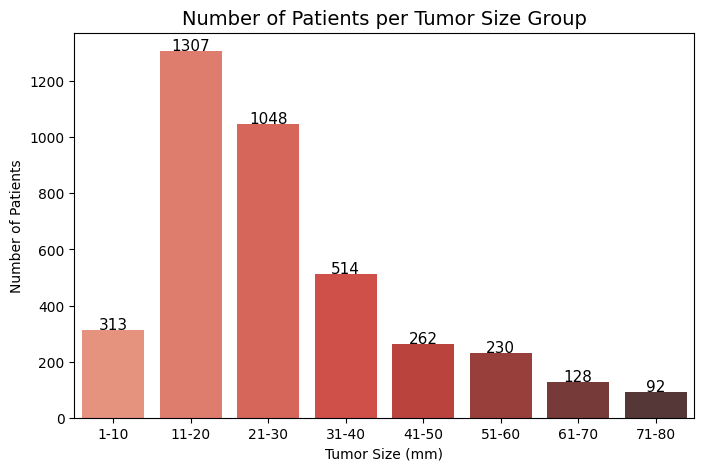

In [36]:
# Plot Tumor Size Group Distribution
plt.figure(figsize=(8,5))
sns.barplot(x=tumor_group_counts.index, y=tumor_group_counts.values, palette="Reds_d")
plt.title("Number of Patients per Tumor Size Group", fontsize=14)
plt.xlabel("Tumor Size (mm)")
plt.ylabel("Number of Patients")

# Add value labels on top of bars
for i, count in enumerate(tumor_group_counts.values):
    plt.text(i, count + 2, str(count), ha='center', fontsize=11)

plt.show()


## Lymph Node Involvement

<div style="border-radius:12px; padding:15px; background:#e0f7fa; border-left:5px solid #00acc1">
<strong>How many patients have regional lymph node involvement? What is the distribution of positive lymph nodes?</strong>
</div>


In [37]:
# Numeric summary of Regional Node Positive
print("Regional Node Positive Statistics:")
print(df['Reginol Node Positive'].describe())

# Count of patients with 0 nodes vs >0 nodes
no_nodes = (df['Reginol Node Positive'] == 0).sum()
with_nodes = (df['Reginol Node Positive'] > 0).sum()

print(f"\nPatients with no lymph node involvement: {no_nodes}")
print(f"Patients with lymph node involvement: {with_nodes}")

# Distribution in bins
node_bins = [0, 1, 2, 5, 10, 15, 20, 25]
node_labels = ['0', '1-2', '3-5', '6-10', '11-15', '16-20', '21-25']

df['Node_Group'] = pd.cut(df['Reginol Node Positive'], bins=node_bins, labels=node_labels, right=True)
node_group_counts = df['Node_Group'].value_counts().sort_index()

print("\nNumber of patients in each lymph node positive group:")
print(node_group_counts)

# Most common lymph node group
most_common_node_group = node_group_counts.idxmax()
count_most_common_nodes = node_group_counts.max()
print(f"\nMost common lymph node involvement group: {most_common_node_group} with {count_most_common_nodes} patients")


Regional Node Positive Statistics:
count    4024.000000
mean        4.158052
std         5.109331
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max        46.000000
Name: Reginol Node Positive, dtype: float64

Patients with no lymph node involvement: 0
Patients with lymph node involvement: 4024

Number of patients in each lymph node positive group:
Node_Group
0        1522
1-2       740
3-5       888
6-10      474
11-15     206
16-20     103
21-25      48
Name: count, dtype: int64

Most common lymph node involvement group: 0 with 1522 patients


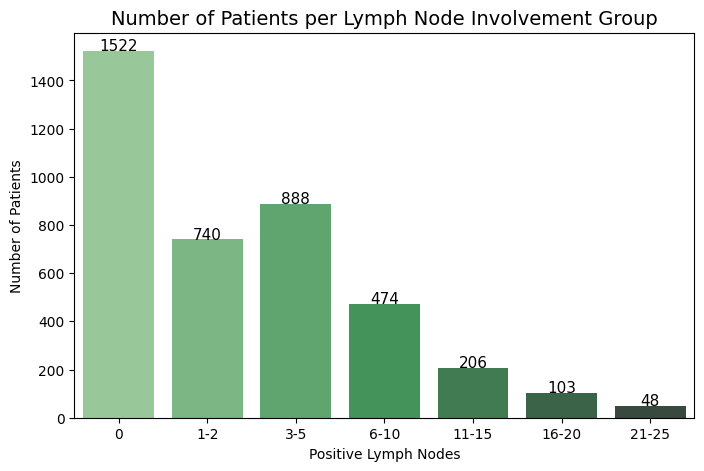

In [38]:
# Plot Lymph Node Positive Distribution
plt.figure(figsize=(8,5))
sns.barplot(x=node_group_counts.index, y=node_group_counts.values, palette="Greens_d")
plt.title("Number of Patients per Lymph Node Involvement Group", fontsize=14)
plt.xlabel("Positive Lymph Nodes")
plt.ylabel("Number of Patients")

# Add value labels
for i, count in enumerate(node_group_counts.values):
    plt.text(i, count + 2, str(count), ha='center', fontsize=11)

plt.show()


## Survival Months Distribution

<div style="border-radius:12px; padding:15px; background:#e0f7fa; border-left:5px solid #00acc1">
<strong>What is the distribution of survival months among patients? Which survival ranges are most common?</strong>
</div>


In [39]:
# Numeric summary
print("Survival Months Statistics:")
print(df['Survival Months'].describe())

# Define survival bins
survival_bins = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180]
survival_labels = ['0-20', '21-40', '41-60', '61-80', '81-100', '101-120', '121-140', '141-160', '161-180']

# Categorize survival months
df['Survival_Group'] = pd.cut(df['Survival Months'], bins=survival_bins, labels=survival_labels, right=True)

# Count of patients in each group
survival_group_counts = df['Survival_Group'].value_counts().sort_index()
print("\nNumber of patients in each survival month group:")
print(survival_group_counts)

# Most common survival range
most_common_survival = survival_group_counts.idxmax()
count_most_common_survival = survival_group_counts.max()
print(f"\nMost common survival range: {most_common_survival} months with {count_most_common_survival} patients")


Survival Months Statistics:
count    4024.000000
mean       71.297962
std        22.921430
min         1.000000
25%        56.000000
50%        73.000000
75%        90.000000
max       107.000000
Name: Survival Months, dtype: float64

Number of patients in each survival month group:
Survival_Group
0-20        139
21-40       214
41-60       913
61-80      1203
81-100     1177
101-120     378
121-140       0
141-160       0
161-180       0
Name: count, dtype: int64

Most common survival range: 61-80 months with 1203 patients


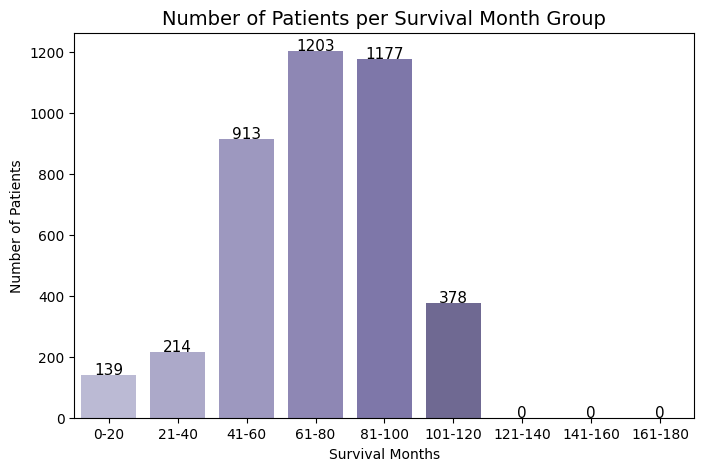

In [40]:
# Plot Survival Month Distribution
plt.figure(figsize=(8,5))
sns.barplot(x=survival_group_counts.index, y=survival_group_counts.values, palette="Purples_d")
plt.title("Number of Patients per Survival Month Group", fontsize=14)
plt.xlabel("Survival Months")
plt.ylabel("Number of Patients")

# Add value labels
for i, count in enumerate(survival_group_counts.values):
    plt.text(i, count + 2, str(count), ha='center', fontsize=11)

plt.show()


## Tumor Size vs Age

<div style="border-radius:12px; padding:15px; background:#e0f7fa; border-left:5px solid #00acc1">
<strong>Is there any relationship between tumor size and patient age? How does tumor size vary across age groups?</strong>
</div>


In [41]:
# Group by age groups and get mean tumor size
age_tumor_mean = df.groupby('Age_Group')['Tumor Size'].mean()
print("Mean Tumor Size per Age Group:")
print(age_tumor_mean)


Mean Tumor Size per Age Group:
Age_Group
21-30    43.400000
31-40    35.043771
41-50    31.974080
51-60    29.796537
61-70    28.475439
71-80          NaN
Name: Tumor Size, dtype: float64


posx and posy should be finite values
posx and posy should be finite values


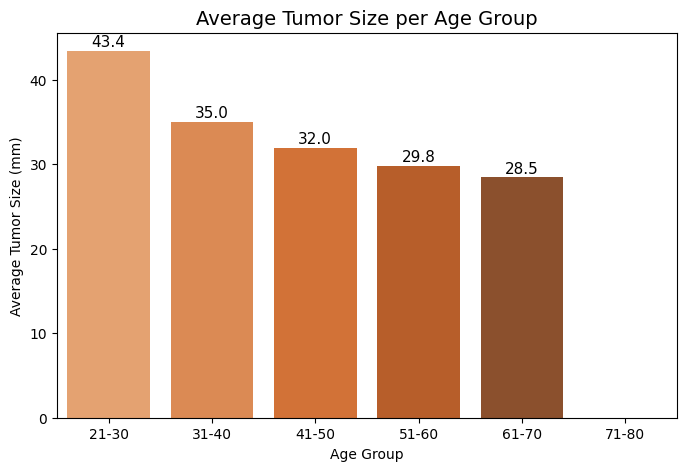

In [42]:
# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=age_tumor_mean.index, y=age_tumor_mean.values, palette="Oranges_d")
plt.title("Average Tumor Size per Age Group", fontsize=14)
plt.xlabel("Age Group")
plt.ylabel("Average Tumor Size (mm)")
for i, val in enumerate(age_tumor_mean.values):
    plt.text(i, val + 0.5, f"{val:.1f}", ha='center', fontsize=11)
plt.show()

## Tumor Size vs Lymph Node Involvement

<div style="border-radius:12px; padding:15px; background:#e0f7fa; border-left:5px solid #00acc1">
<strong>Does tumor size correlate with the number of positive lymph nodes? Which tumor sizes are associated with higher lymph node involvement?</strong>
</div>


In [43]:
# Mean positive nodes per tumor size group
tumor_node_mean = df.groupby('Tumor_Size_Group')['Reginol Node Positive'].mean()
print("Mean Positive Lymph Nodes per Tumor Size Group:")
print(tumor_node_mean)


Mean Positive Lymph Nodes per Tumor Size Group:
Tumor_Size_Group
1-10     2.380192
11-20    3.078041
21-30    4.059160
31-40    4.951362
41-50    5.652672
51-60    5.604348
61-70    6.531250
71-80    6.076087
Name: Reginol Node Positive, dtype: float64


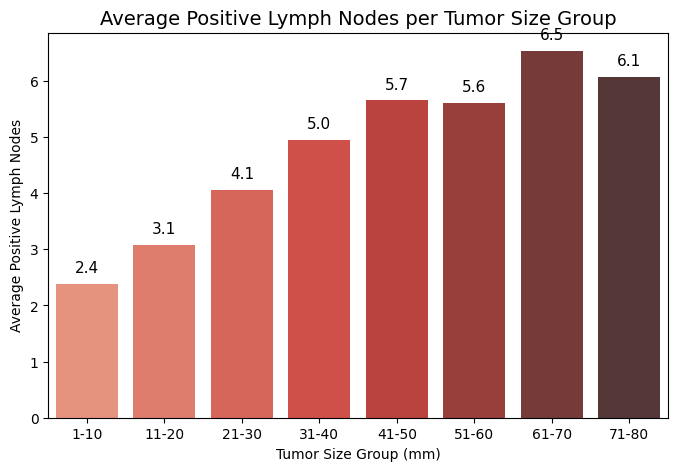

In [44]:
# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=tumor_node_mean.index, y=tumor_node_mean.values, palette="Reds_d")
plt.title("Average Positive Lymph Nodes per Tumor Size Group", fontsize=14)
plt.xlabel("Tumor Size Group (mm)")
plt.ylabel("Average Positive Lymph Nodes")
for i, val in enumerate(tumor_node_mean.values):
    plt.text(i, val + 0.2, f"{val:.1f}", ha='center', fontsize=11)
plt.show()

## Tumor Size vs Survival Months

<div style="border-radius:12px; padding:15px; background:#e0f7fa; border-left:5px solid #00acc1">
<strong>How does tumor size impact survival months? Do patients with larger tumors have shorter survival?</strong>
</div>


In [45]:
tumor_survival_mean = df.groupby('Tumor_Size_Group')['Survival Months'].mean()
print("Average Survival Months per Tumor Size Group:")
print(tumor_survival_mean)


Average Survival Months per Tumor Size Group:
Tumor_Size_Group
1-10     74.984026
11-20    73.115532
21-30    71.645038
31-40    68.745136
41-50    66.961832
51-60    72.382609
61-70    64.531250
71-80    70.945652
Name: Survival Months, dtype: float64


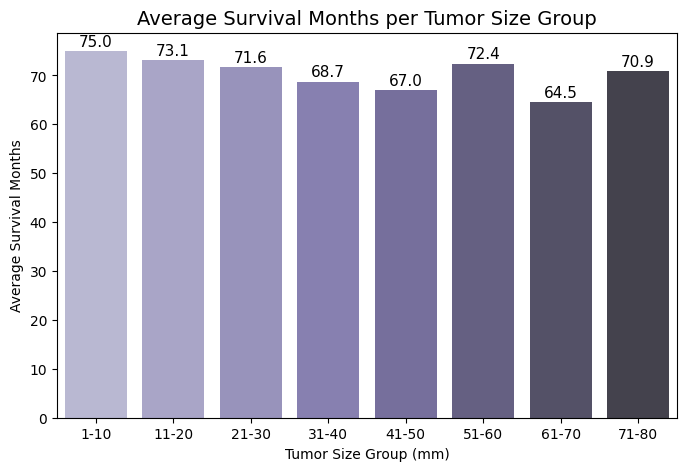

In [46]:
plt.figure(figsize=(8,5))
sns.barplot(x=tumor_survival_mean.index, y=tumor_survival_mean.values, palette="Purples_d")
plt.title("Average Survival Months per Tumor Size Group", fontsize=14)
plt.xlabel("Tumor Size Group (mm)")
plt.ylabel("Average Survival Months")
for i, val in enumerate(tumor_survival_mean.values):
    plt.text(i, val + 1, f"{val:.1f}", ha='center', fontsize=11)
plt.show()


## Lymph Node Involvement vs Survival Months

<div style="border-radius:12px; padding:15px; background:#e0f7fa; border-left:5px solid #00acc1">
<strong>How does lymph node involvement affect survival? Do patients with more positive nodes have lower survival months?</strong>
</div>


In [47]:
node_survival_mean = df.groupby('Node_Group')['Survival Months'].mean()
print("Average Survival Months per Lymph Node Group:")
print(node_survival_mean)

Average Survival Months per Lymph Node Group:
Node_Group
0        73.831143
1-2      72.860811
3-5      70.235360
6-10     68.864979
11-15    66.432039
16-20    61.757282
21-25    64.020833
Name: Survival Months, dtype: float64


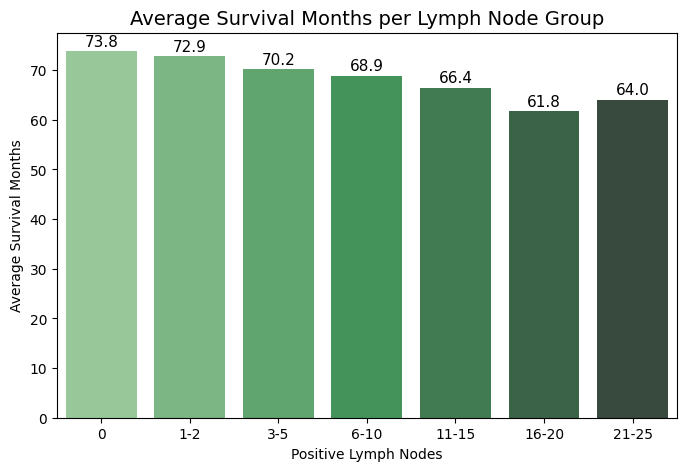

In [48]:
plt.figure(figsize=(8,5))
sns.barplot(x=node_survival_mean.index, y=node_survival_mean.values, palette="Greens_d")
plt.title("Average Survival Months per Lymph Node Group", fontsize=14)
plt.xlabel("Positive Lymph Nodes")
plt.ylabel("Average Survival Months")
for i, val in enumerate(node_survival_mean.values):
    plt.text(i, val + 1, f"{val:.1f}", ha='center', fontsize=11)
plt.show()


## Age vs Survival Months

<div style="border-radius:12px; padding:15px; background:#e0f7fa; border-left:5px solid #00acc1">
<strong>Does patient age affect survival months? Which age groups have better or worse survival outcomes?</strong>
</div>


In [49]:
age_survival_mean = df.groupby('Age_Group')['Survival Months'].mean()
print("Average Survival Months per Age Group:")
print(age_survival_mean)

Average Survival Months per Age Group:
Age_Group
21-30    67.800000
31-40    67.070707
41-50    72.744983
51-60    71.720058
61-70    70.383333
71-80          NaN
Name: Survival Months, dtype: float64


posx and posy should be finite values
posx and posy should be finite values


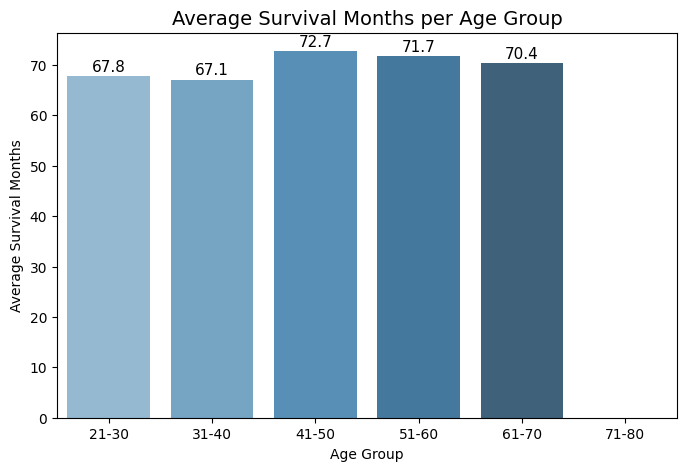

In [50]:
plt.figure(figsize=(8,5))
sns.barplot(x=age_survival_mean.index, y=age_survival_mean.values, palette="Blues_d")
plt.title("Average Survival Months per Age Group", fontsize=14)
plt.xlabel("Age Group")
plt.ylabel("Average Survival Months")
for i, val in enumerate(age_survival_mean.values):
    plt.text(i, val + 1, f"{val:.1f}", ha='center', fontsize=11)
plt.show()


## Numerical Feature Correlation

<div style="border-radius:12px; padding:15px; background:#e0f7fa; border-left:5px solid #00acc1">
<strong>How are the numerical features correlated with each other? Which features are most strongly associated with survival?</strong>
</div>


In [51]:
corr_matrix = df[['Age', 'Tumor Size', 'Reginol Node Positive', 'Survival Months']].corr()
print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
                            Age  Tumor Size  Reginol Node Positive  \
Age                    1.000000   -0.077215               0.012586   
Tumor Size            -0.077215    1.000000               0.242322   
Reginol Node Positive  0.012586    0.242322               1.000000   
Survival Months       -0.009390   -0.086901              -0.135214   

                       Survival Months  
Age                          -0.009390  
Tumor Size                   -0.086901  
Reginol Node Positive        -0.135214  
Survival Months               1.000000  


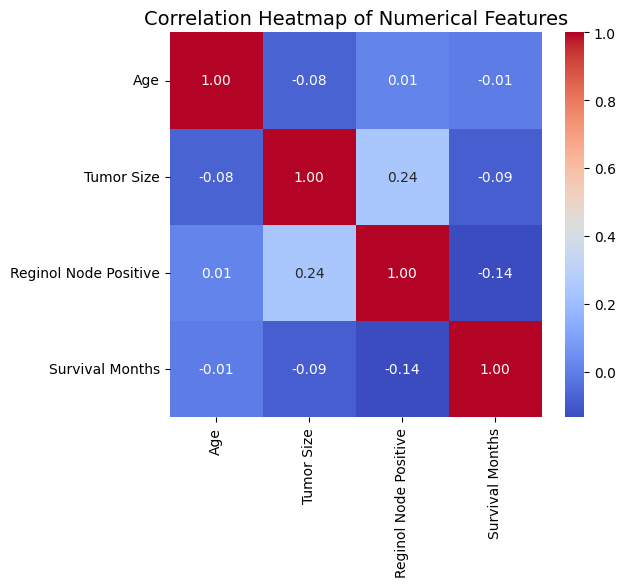

In [52]:

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.show()

<div style="border-radius:12px; padding:15px; background:#e0f7fa; border-left:5px solid #00acc1">
<strong>Thank you for exploring this Breast Cancer EDA notebook! 🎉</strong>  

I hope you found this notebook **informative and helpful**.  

If you liked it, please **upvote ⭐** and **follow** for more **data science and machine learning projects**!  

Stay tuned for more notebooks on **exploratory analysis, modeling, and AI projects**.  
</div>
